<a href="https://colab.research.google.com/github/laniquahendricks2/laniquahendricks2.github.io/blob/main/UNICEF_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "🌍 A Global Gap in Access to Life-Saving Treatment"
author: "Laniqua Hendricks"

format:
  html:
    theme: cosmo
    embed-resources: true
    toc: true
    number-sections: true
    include-in-header:
      text: |
        <style>
        body {
          background-color: #f6fbf7;
          font-family: "Segoe UI", sans-serif;
        }

        main.content {
          background-color: white;
          padding: 2rem;
          border-radius: 16px;
          box-shadow: 0 4px 14px rgba(0, 0, 0, 0.08);
        }

        h1 {
          color: #1b5e20;
          font-weight: 700;
        }

        h2 {
          color: #2e7d32;
          margin-top: 2rem;
        }

        .callout {
          border-radius: 12px;
        }

        img {
          border-radius: 12px;
        }
        </style>

execute:
  echo: false
  warning: false
  message: false
---

In [ ]:
#| include: false
!pip install polars plotnine quarto-cli

In [ ]:
#| include: false
indicator = pl.read_csv("unicef_indicator_2.csv")
metadata = pl.read_csv("unicef_metadata.csv")

In [ ]:
#| include: false
print("Indicator shape:", indicator.shape)
print("Metadata shape:", metadata.shape)

print("Number of countries:", indicator.select(pl.col("country").n_unique()).item())

print("Years available:")
print(
    indicator
    .select("time_period")
    .unique()
    .sort("time_period")
)

Indicator shape: (598, 14)
Metadata shape: (13715, 15)
Number of countries: 92
Years available:
shape: (20, 1)
┌─────────────┐
│ time_period │
│ ---         │
│ i64         │
╞═════════════╡
│ 2005        │
│ 2006        │
│ 2007        │
│ 2008        │
│ 2009        │
│ …           │
│ 2020        │
│ 2021        │
│ 2022        │
│ 2023        │
│ 2024        │
└─────────────┘


In [ ]:
#| include: false
summary_stats = latest_country.select([
    pl.col("obs_value").mean().alias("Average treatment rate"),
    pl.col("obs_value").median().alias("Median treatment rate"),
    pl.col("obs_value").min().alias("Minimum treatment rate"),
    pl.col("obs_value").max().alias("Maximum treatment rate")
])

summary_stats

Average treatment rate,Median treatment rate,Minimum treatment rate,Maximum treatment rate
f64,f64,f64,f64
15.970652,10.7,0.0,60.2


In [ ]:
#| include: false
latest_country.select([
    pl.col("obs_value").null_count().alias("Missing treatment values")
])

Missing treatment values
u32
0


In [ ]:
#| include: false
highest = (
    latest_country
    .sort("obs_value", descending=True)
    .head(3)
    .select(["country", "obs_value"])
)

lowest = (
    latest_country
    .sort("obs_value")
    .head(3)
    .select(["country", "obs_value"])
)

print(highest)
print(lowest)

shape: (3, 2)
┌─────────────────────────────────┬───────────┐
│ country                         ┆ obs_value │
│ ---                             ┆ ---       │
│ str                             ┆ f64       │
╞═════════════════════════════════╪═══════════╡
│ Bolivia                         ┆ 60.2      │
│ Sierra Leone                    ┆ 53.4      │
│ Korea, Democratic People's Rep… ┆ 45.0      │
└─────────────────────────────────┴───────────┘
shape: (3, 2)
┌───────────┬───────────┐
│ country   ┆ obs_value │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Sri Lanka ┆ 0.0       │
│ Peru      ┆ 0.2       │
│ Namibia   ┆ 0.2       │
└───────────┴───────────┘


In [ ]:
#| include: false
print(indicator.columns)
print(metadata.columns)

['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'indicator', 'time_period', 'obs_value', 'sex', 'unit_multiplier', 'unit_of_measure', 'observation_status', 'observation_confidentaility', 'time_period_activity_related_to_when_the_data_are_collected', 'current_age']
['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'year', 'Population, total', 'GDP per capita (constant 2015 US$)', 'GNI (current US$)', 'Inflation, consumer prices (annual %)', 'Life expectancy at birth, total (years)', 'Military expenditure (% of GDP)', 'Fossil fuel energy consumption (% of total)', 'GDP growth (annual %)', 'Birth rate, crude (per 1,000 people)', 'Hospital beds (per 1,000 people)']


In [ ]:
#| include: false
latest_year = indicator["time_period"].max()
print(latest_year)

2024


In [ ]:
#| include: false
latest = indicator.filter(pl.col("time_period") == latest_year)

latest.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",9.5
"""Lesotho""",11.2
"""Lesotho""",10.4
"""Mali""",3.3
"""Mali""",3.5


In [ ]:
#| include: false
latest_total = latest.filter(pl.col("sex") == "Total")

latest_total.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",10.4
"""Mali""",3.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
#| include: false
top10 = (
    latest_total
    .sort("obs_value", descending=True)
    .head(10)
)

top10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Zambia""",38.4
"""Nigeria""",23.6
"""Lesotho""",10.4
"""Mali""",3.4


In [ ]:
#| include: false
bottom10 = (
    latest_total
    .sort("obs_value")
    .head(10)
)

bottom10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Mali""",3.4
"""Lesotho""",10.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
#| include: false
latest_total_year = latest_total.rename({"time_period": "year"})

In [ ]:
#| include: false
scatter_data = latest_total_year.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

In [ ]:
#| include: false
scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Lesotho""",2024,10.4,991.069662
"""Mali""",2024,3.4,909.755318
"""Nigeria""",2024,23.6,2324.648812
"""Zambia""",2024,38.4,1343.389664


In [ ]:
#| include: false
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort(["country", "time_period"])
    .group_by("country")
    .tail(1)
)

In [ ]:
#| include: false
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort("time_period")
    .group_by("country")
    .agg([
        pl.col("time_period").last().alias("year"),
        pl.col("obs_value").last().alias("obs_value")
    ])
)

latest_country.head()

country,year,obs_value
str,i64,f64
"""Armenia""",2016,2.0
"""Malawi""",2020,22.0
"""Gambia""",2020,21.1
"""Iraq""",2018,5.2
"""El Salvador""",2021,29.4


In [ ]:
#| include: false
scatter_data = latest_country.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Afghanistan""",2023,24.0,378.066303
"""Albania""",2018,7.4,4893.823755
"""Armenia""",2016,2.0,3533.885036
"""Azerbaijan""",2023,9.6,5668.610213
"""Bangladesh""",2019,35.0,1564.208024


In [ ]:
#| include: false
print(scatter_data.shape)
scatter_data.head()

(91, 16)


country,year,obs_value,alpha_2_code,alpha_3_code,numeric_code,"Population, total",GDP per capita (constant 2015 US$),GNI (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Military expenditure (% of GDP),Fossil fuel energy consumption (% of total),GDP growth (annual %),"Birth rate, crude (per 1,000 people)","Hospital beds (per 1,000 people)"
str,i64,f64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""",2023,24.0,"""AF""","""AFG""",4,41454761,378.066303,1.7235e10,-4.644709,66.035,null,null,2.266944,35.437,0.35
"""Albania""",2018,7.4,"""AL""","""ALB""",8,2607733,4893.823755,1.5362e10,2.02806,79.238,1.160545,0.0,3.671419,10.898,2.83
"""Armenia""",2016,2.0,"""AM""","""ARM""",51,2992300,3533.885036,1.0791e10,-1.403608,74.868293,4.090349,0.0,0.2,13.5,4.28
"""Azerbaijan""",2023,9.6,"""AZ""","""AZE""",31,10153958,5668.610213,6.9386e10,8.78543,74.429,4.922414,0.0,1.354477,11.1,3.68
"""Bangladesh""",2019,35.0,"""BD""","""BGD""",50,164913055,1564.208024,3.6562e11,5.591996,72.625,1.244101,0.0,7.881915,20.131,0.89


## Introduction

Diarrhoea remains a major cause of mortality among children under five, even though effective treatment is inexpensive and widely available. UNICEF measures the percentage of children under five with diarrhoea who receive oral rehydration salts (ORS) and zinc, the recommended treatment for preventing severe dehydration and death. Linked with GDP per capita data, this indicator provides insight into whether higher national income is associated with greater access to lifesaving treatment. Wide variation between countries suggests that treatment coverage is influenced not only by economic wealth, but also by healthcare access, public health policy, and investment in child health systems.

![Children receiving oral rehydration salts and zinc treatment](child_treatment.jpg)

::: {.callout-important}
## 💡 Did you know?

More than half a million children die each year from diarrhoea related illnesses, despite the existence of simple and inexpensive treatment.
:::

## 📊 What does the data show?

The UNICEF treatment coverage dataset contains 598 observations across 92 countries between 2005 and 2024. The dataset measures the percentage of children under five with diarrhoea who receive oral rehydration salts (ORS) and zinc. There are no missing values in the treatment rate variable. The average treatment rate is approximately 16 percent, although values vary substantially between countries, ranging from 0 percent in Sri Lanka to 60.2 percent in Bolivia. The median value of 10.7 percent suggests that most countries report relatively low coverage.

In [ ]:
#| include: false
!pip install geopandas

In [ ]:
#| include: false
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#| include: false
latest_map = latest_country.to_pandas()

NameError: name 'latest_country' is not defined

In [ ]:
#| include: false
import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
#| include: false
latest_map = latest_country.to_pandas()

world_data = world.merge(
    latest_map,
    left_on="NAME",
    right_on="country",
    how="left"
)

NameError: name 'latest_country' is not defined

## 🌍 Global Patterns in Treatment Coverage

The map highlights substantial differences in access to diarrhoea treatment across countries. Higher treatment coverage is concentrated in parts of southern and eastern Africa, while lower coverage is visible in several countries across West Africa and parts of Asia. Large areas of the world also have no available data, emphasising continuing gaps in health monitoring. The uneven pattern suggests that access to treatment is shaped not only by national income, but also by differences in healthcare systems, public health programmes, and the availability of oral rehydration salts and zinc.

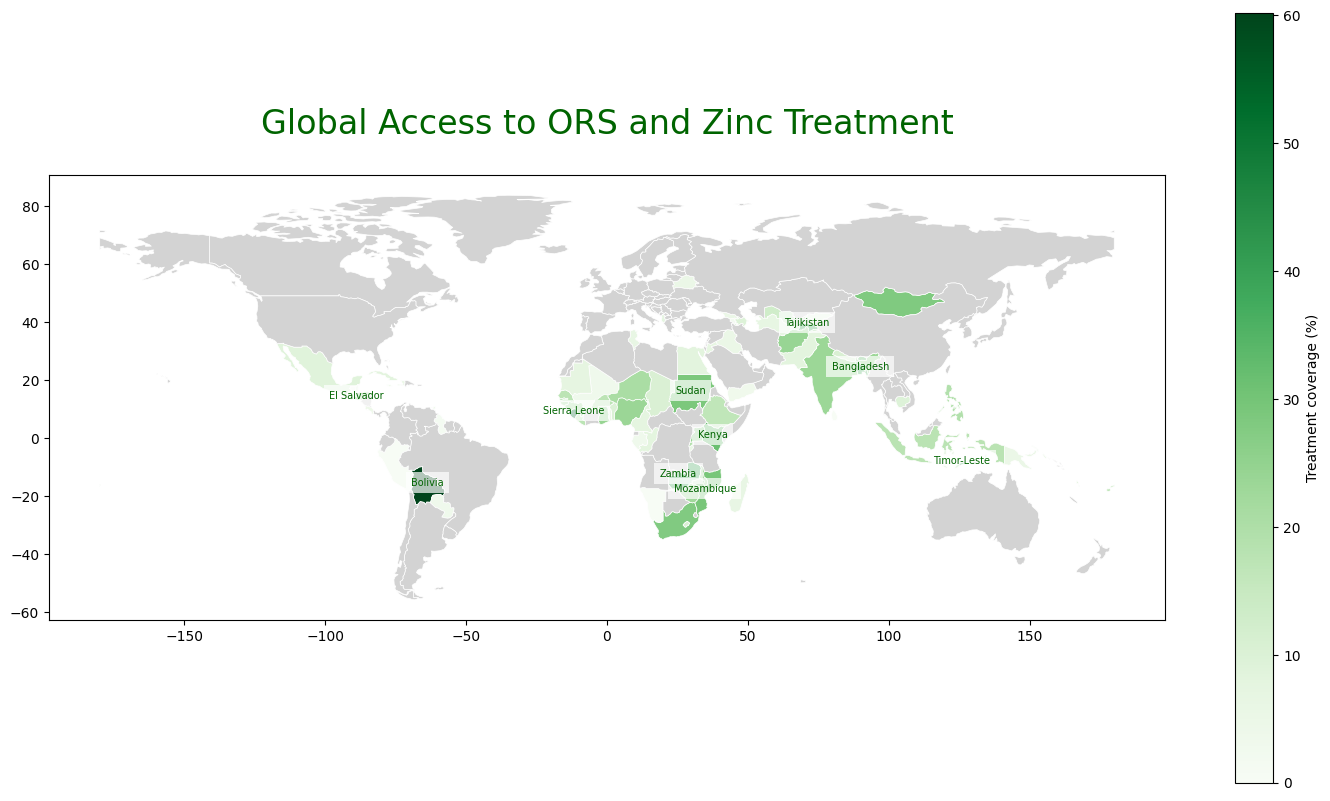

In [ ]:
#| echo: false
import geopandas as gpd
import matplotlib.pyplot as plt
import polars as pl

# Ensure `latest_country` is defined
indicator = pl.read_csv("/content/unicef_indicator_2.csv")
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort("time_period")
    .group_by("country")
    .agg([
        pl.col("time_period").last().alias("year"),
        pl.col("obs_value").last().alias("obs_value")
    ])
)

# Prepare latest_map
latest_map = latest_country.to_pandas()

# Load world data
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Merge world and latest_map to create world_data
world_data = world.merge(
    latest_map,
    left_on="NAME",
    right_on="country",
    how="left"
)

fig, ax = plt.subplots(figsize=(18, 10))

world_data_clean = world_data[world_data["NAME"] != "Antarctica"]

world_data_clean.plot(
    column="obs_value",
    cmap="Greens",
    edgecolor="white",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Treatment coverage (%)"},
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

# Filter out Bhutan and then select the top 10 countries for annotation
top10 = (
    world_data_clean[world_data_clean['country'] != 'Bhutan']
    .nlargest(10, "obs_value")
)

for _, row in top10.iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        row["country"],
        fontsize=7,  # Reduced font size for less clutter
        ha="center",
        color="darkgreen",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

ax.set_title(
    "Global Access to ORS and Zinc Treatment",
    fontsize=24,
    color="darkgreen",
    pad=30
)
plt.show()

::: {.callout-tip}
## How to read this map

Darker green countries have higher levels of ORS and zinc treatment coverage among children with diarrhoea. Light grey countries either have very low coverage or no available data.
:::

::: {.callout-tip}
## 🌟 Country Spotlight: Bolivia vs Sierra Leone

Bolivia reports the highest treatment coverage at 60.2%, slightly ahead of Sierra Leone at 53.4%. Both countries outperform many wealthier nations, suggesting that targeted health policy may matter more than income alone.
:::

In [ ]:
#| include: false
top10 = (
    latest_country
    .sort("obs_value", descending=True)
    .head(10)
)

## Highest Treatment Coverage in 2024

Although global treatment coverage remains low, some countries report substantially higher rates than others. The chart below highlights the ten countries with the highest reported coverage of oral rehydration salts and zinc treatment in 2024, illustrating the wide variation in access to recommended diarrhoea treatment across countries.

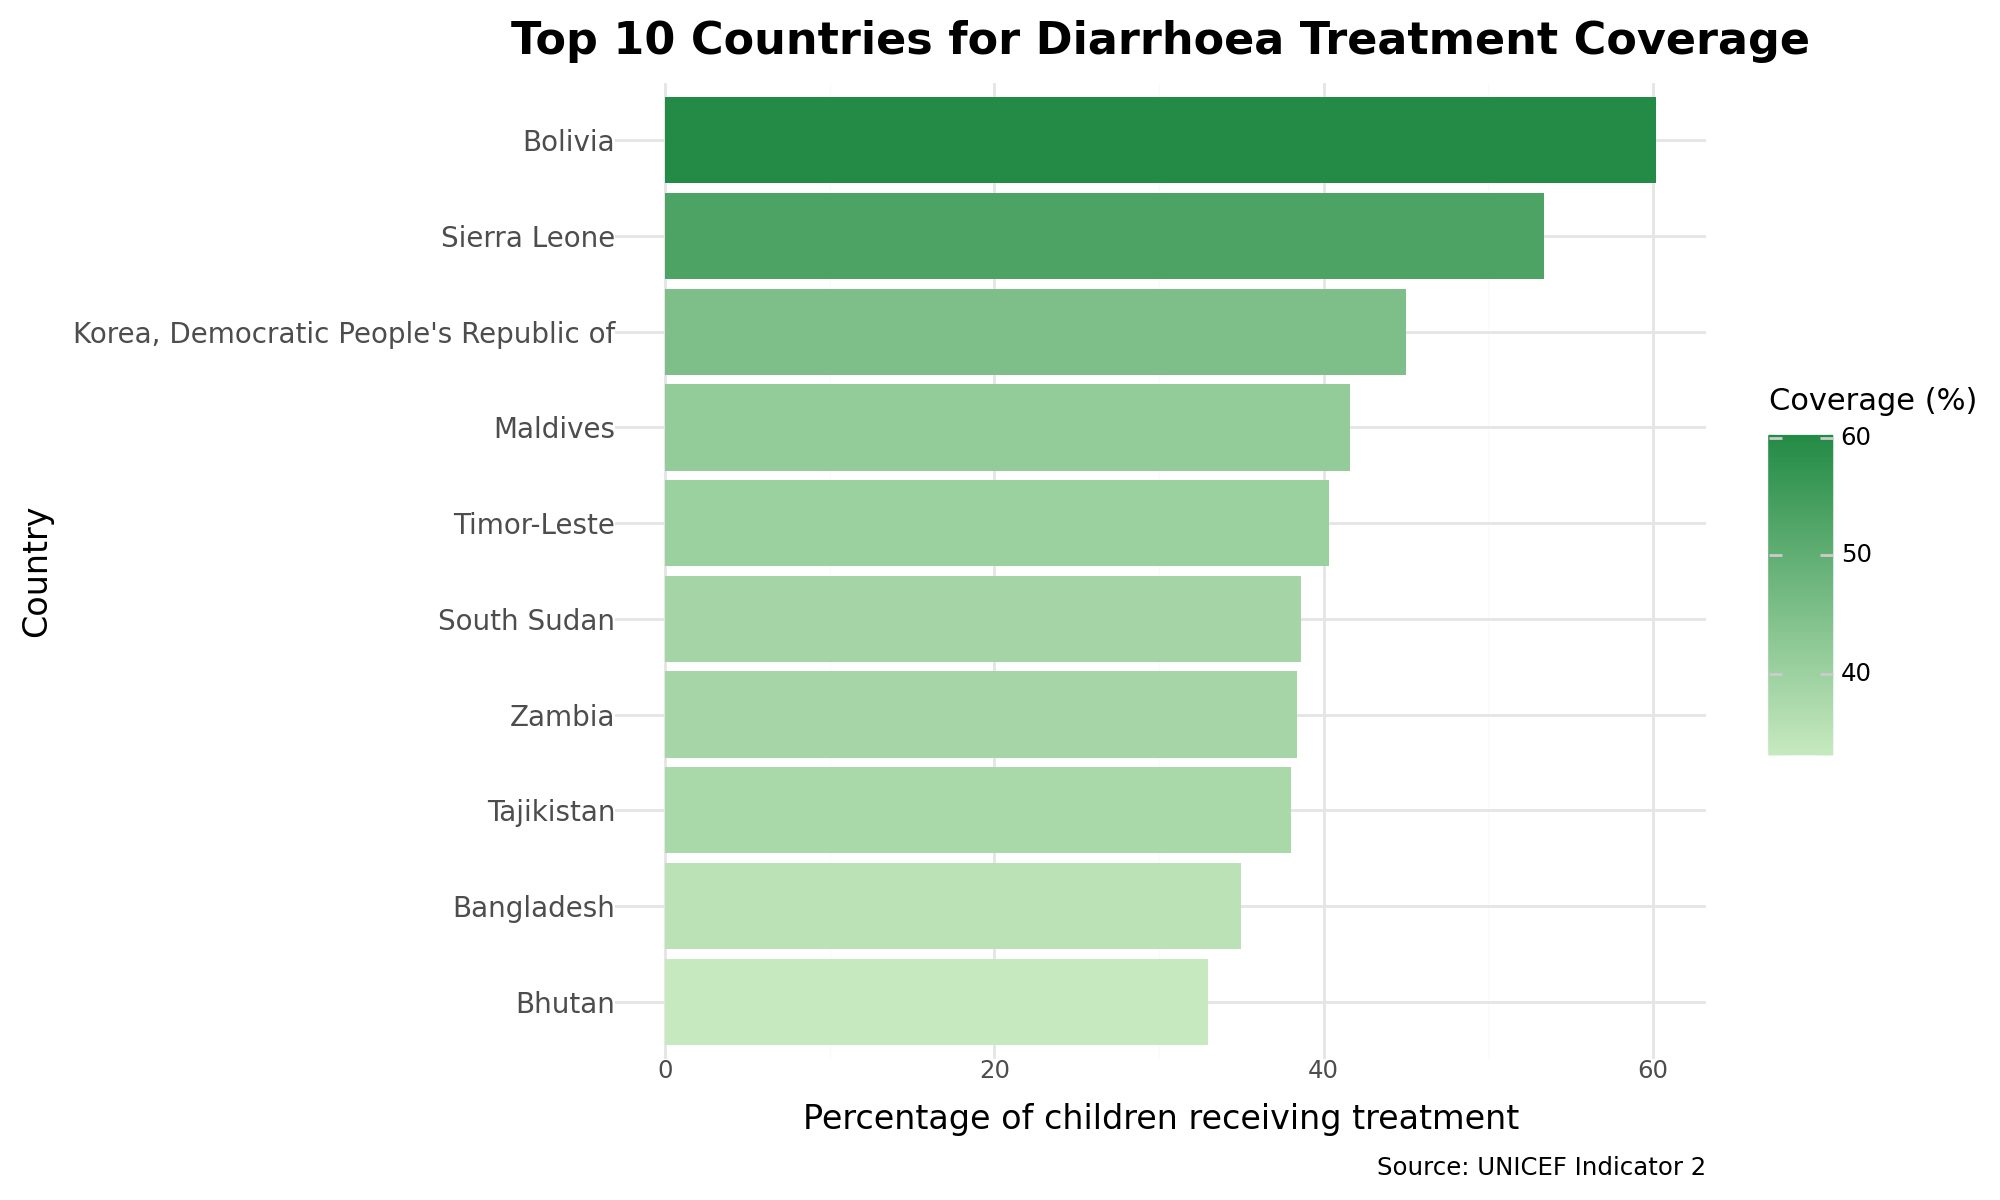

In [ ]:
#| echo: false
from plotnine import ggplot, aes, geom_col, coord_flip, scale_fill_gradient, labs, theme_minimal, element_text, theme

# Ensure latest_country is defined if this cell is run independently
# Based on the kernel state, latest_country is already available as a Polars DataFrame

top10 = (
    latest_country
    .sort("obs_value", descending=True)
    .head(10)
)

(    ggplot(
        top10.to_pandas(),
        aes(
            x="reorder(country, obs_value)",
            y="obs_value",
            fill="obs_value"
        )
    )
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low="#C7E9C0", high="#238B45")
    + labs(
        title="Top 10 Countries for Diarrhoea Treatment Coverage",
        x="Country",
        y="Percentage of children receiving treatment",
        fill="Coverage (%)",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text_y=element_text(size=10),
        legend_position="right"
    )
)

In [ ]:
#| include: false
selected = (
    indicator
    .filter(
        (pl.col("sex") == "Total") &
        (pl.col("country").is_in(["Zambia", "Lesotho", "Mali"]))
    )
    .select(["country", "time_period", "obs_value"])
)

## Does Wealth Improve Treatment Access? 📈

Higher national income is often assumed to improve access to healthcare, but this relationship is not always straightforward. By combining treatment coverage data with GDP per capita for the same year, it is possible to examine whether children in wealthier countries are more likely to receive oral rehydration salts and zinc treatment.

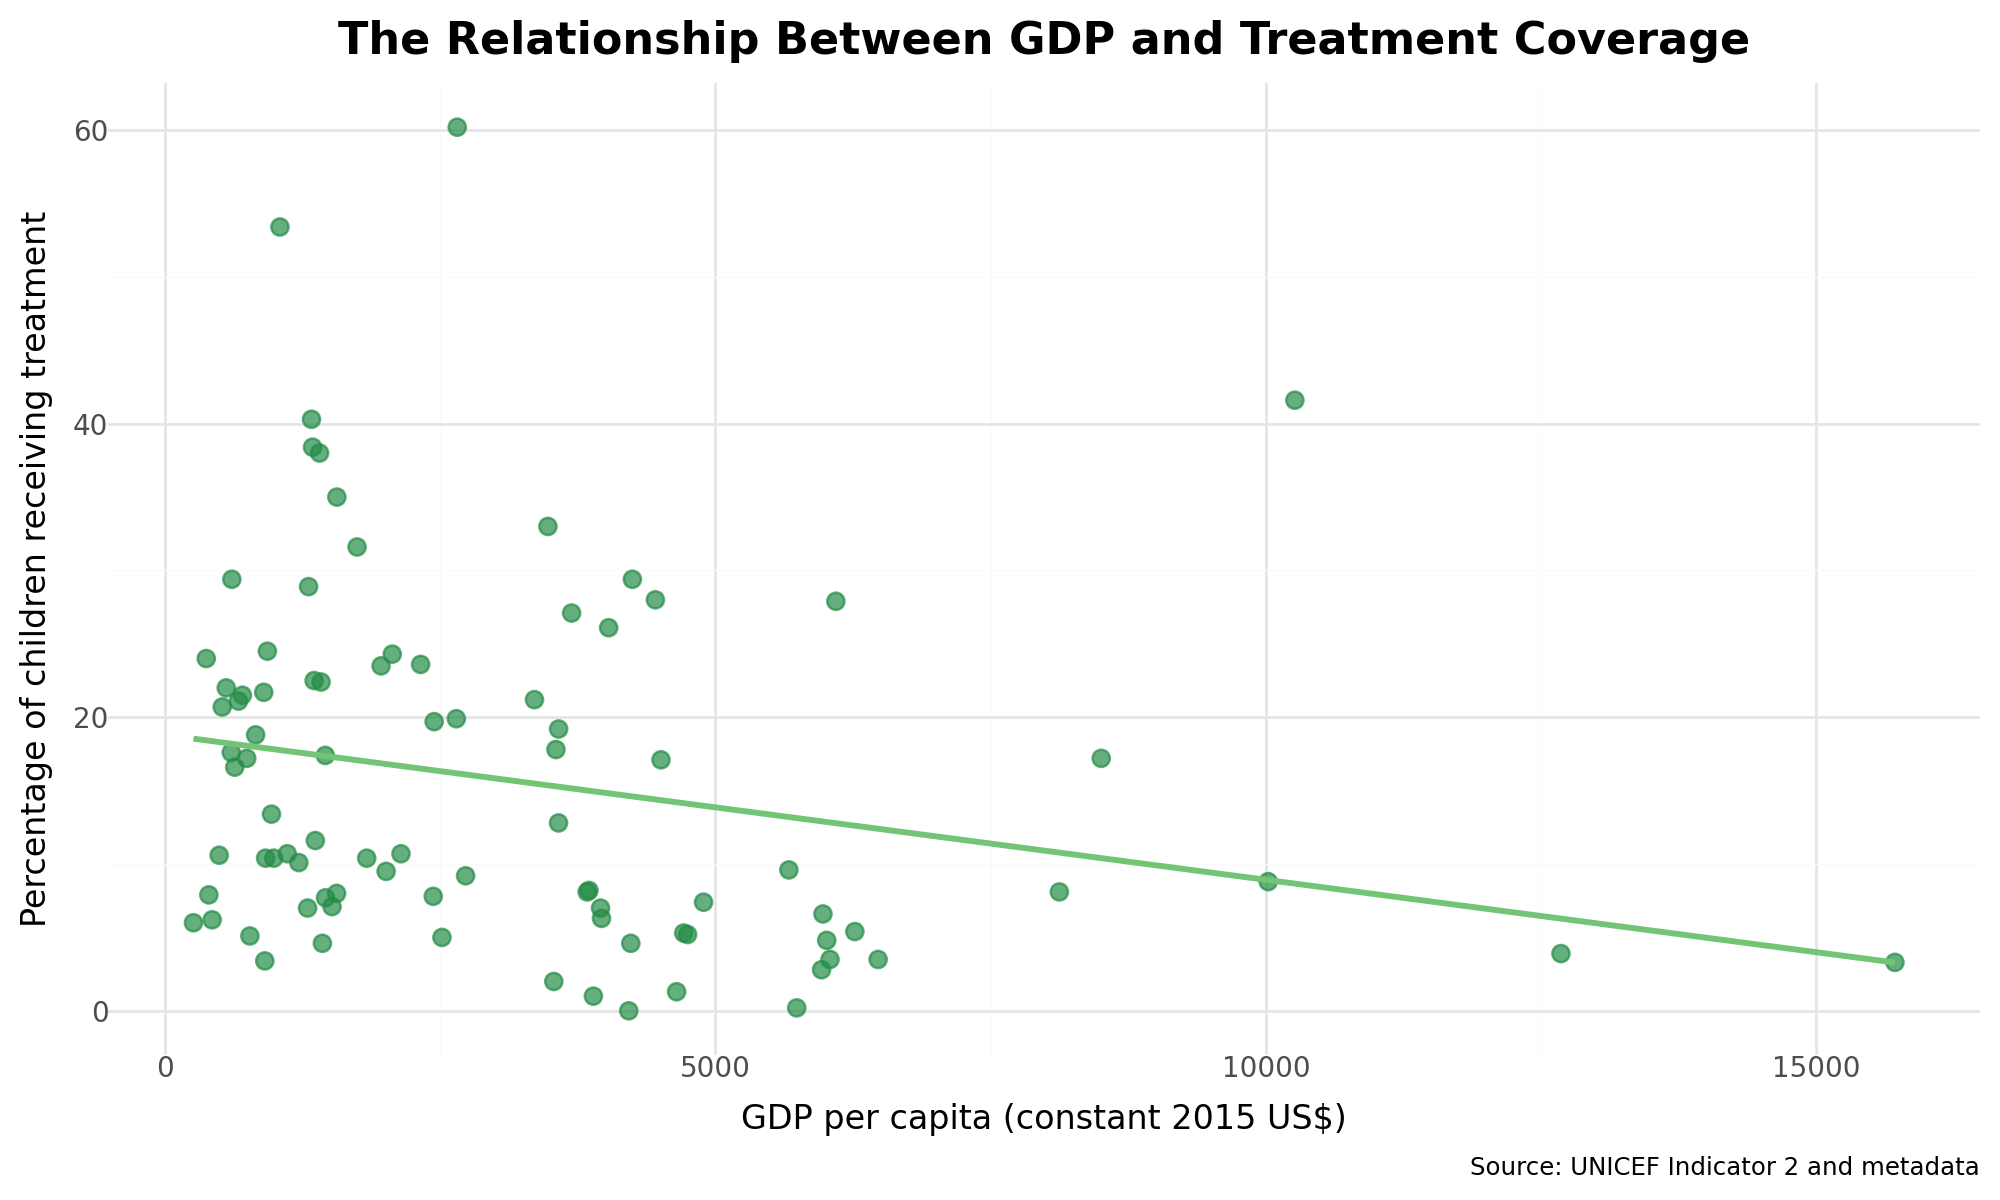

In [ ]:
#| echo: false
import polars as pl
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_minimal, element_text, theme

# Re-create scatter_data to ensure it's defined in the current scope
# assuming 'latest_country' and 'metadata' DataFrames are already in the kernel's memory

# Explicitly load metadata
metadata = pl.read_csv("/content/unicef_metadata.csv")

scatter_data = latest_country.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

scatter_data = scatter_data.drop_nulls(
    ["GDP per capita (constant 2015 US$)", "obs_value"]
)
(
    ggplot(
        scatter_data.to_pandas(),
        aes(
            x="GDP per capita (constant 2015 US$)",
            y="obs_value"
        )
    )
    + geom_point(size=3, color="#238B45", alpha=0.7)
    + geom_smooth(method="lm", se=False, color="#74C476", size=1.2)
    + labs(
        title="The Relationship Between GDP and Treatment Coverage",
        x="GDP per capita (constant 2015 US$)",
        y="Percentage of children receiving treatment",
        caption="Source: UNICEF Indicator 2 and metadata"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10)
    )
)

The scatterplot shows only a weak relationship between GDP per capita and treatment coverage. Several lower income countries report relatively high treatment rates, while some wealthier countries report lower levels of coverage. This suggests that income alone does not determine whether children receive treatment. Government policy, healthcare access, public awareness, and investment in child health services may play a more important role.

![Oral rehydration salts can prevent most deaths from diarrhoea when treatment is available in time.](ors_treatment.png)

## Changes in Treatment Coverage Over Time 🔄

Treatment coverage has not changed at the same pace across all countries. The final chart follows Lesotho, Mali, and Zambia over time because each country illustrates a different pattern of change. Zambia shows gradual improvement, while Lesotho and Mali experience more limited progress and periods of decline. Comparing these countries demonstrates that access to treatment can improve over time, but progress is often uneven and shaped by differences in healthcare systems, policy priorities, and investment in child health.

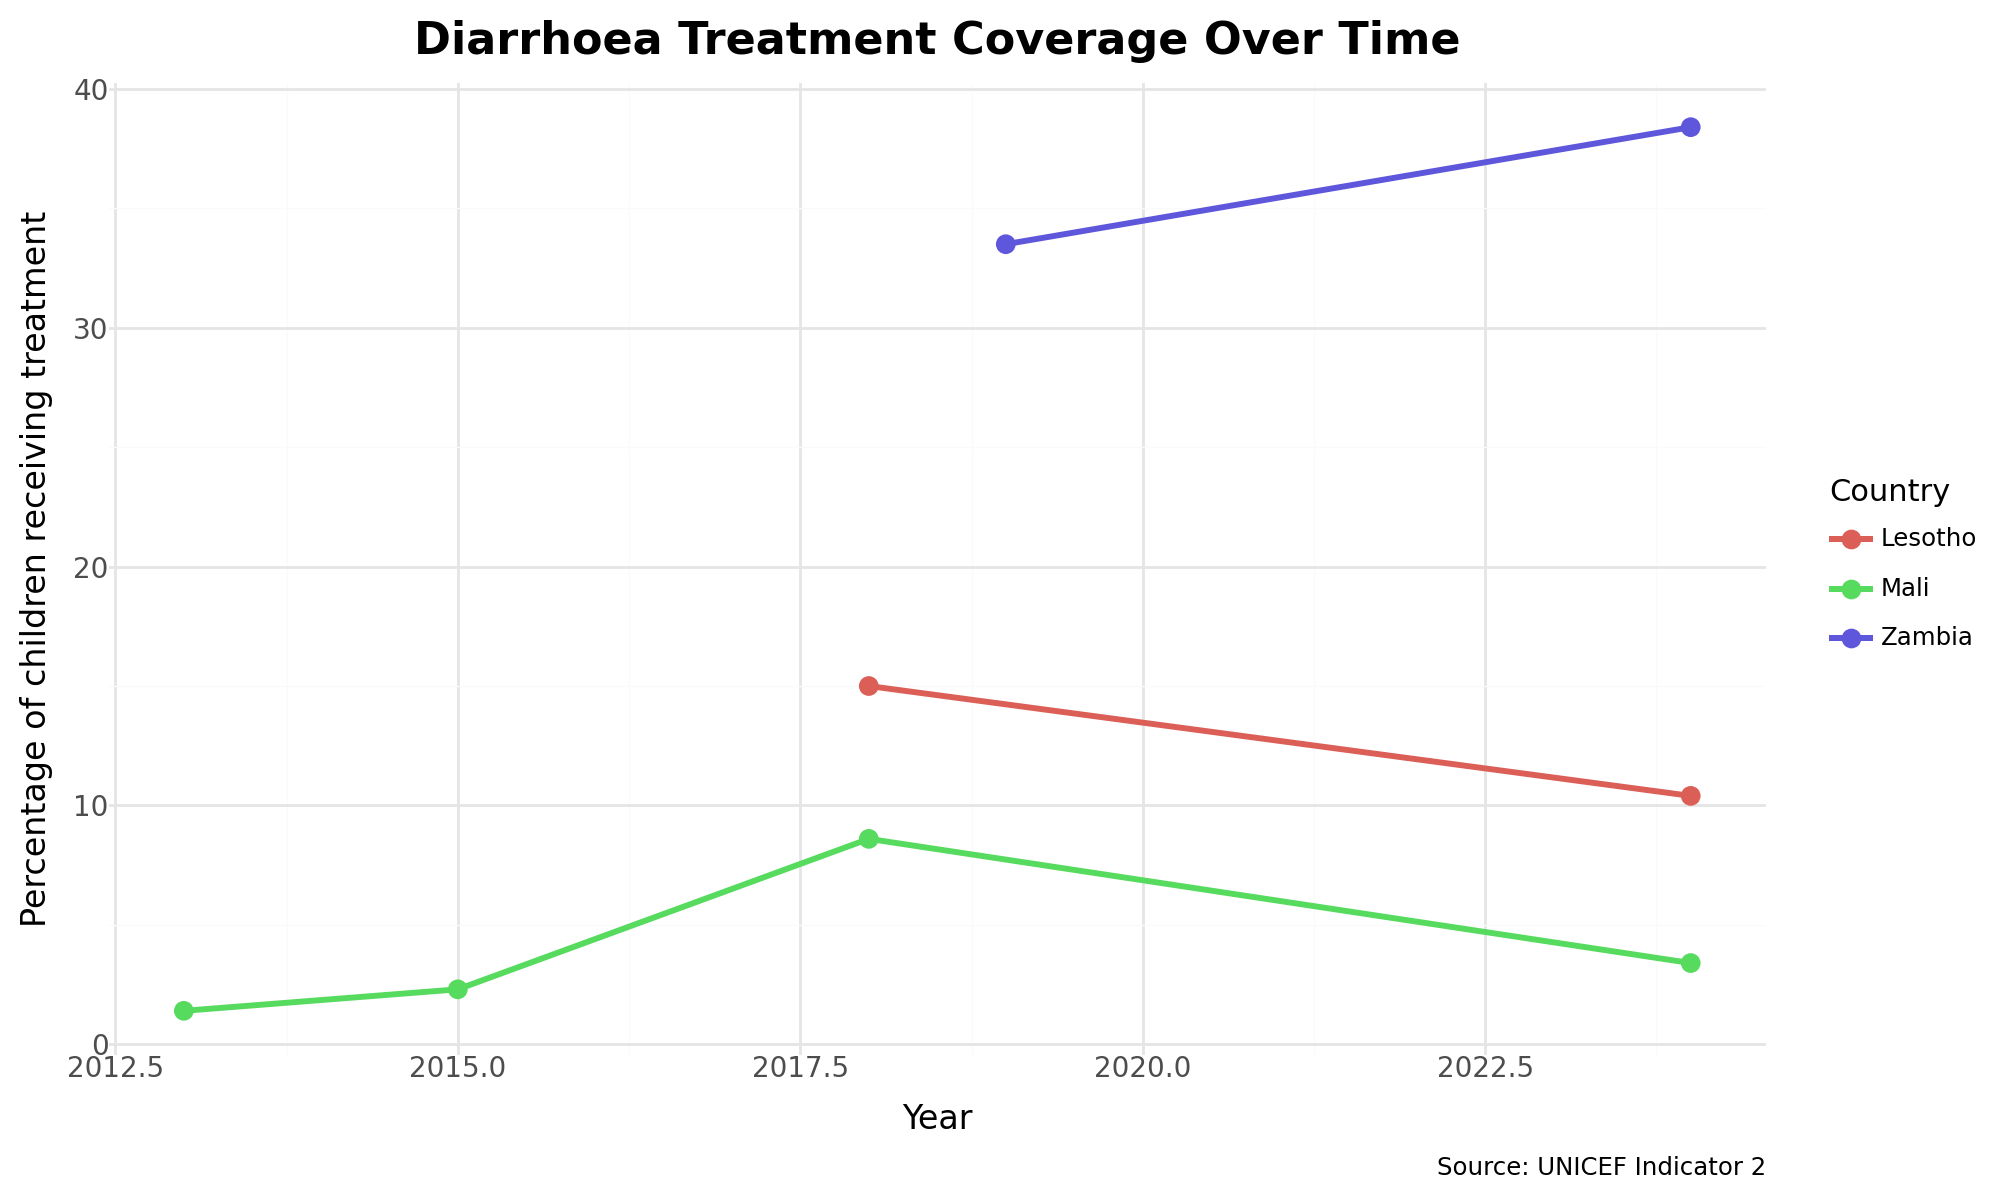

In [ ]:
#| echo: false
import polars as pl
from plotnine import ggplot, aes, geom_line, geom_point, labs, theme_minimal, element_text

indicator = pl.read_csv("/content/unicef_indicator_2.csv")
metadata = pl.read_csv("/content/unicef_metadata.csv")

selected = (
    indicator
    .filter(
        (pl.col("sex") == "Total") &
        (pl.col("country").is_in(["Zambia", "Lesotho", "Mali"]))
    )
    .select(["country", "time_period", "obs_value"])
)

(
    ggplot(
        selected.to_pandas(),
        aes(
            x="time_period",
            y="obs_value",
            color="country",
            group="country"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3)
    + labs(
        title="Diarrhoea Treatment Coverage Over Time",
        x="Year",
        y="Percentage of children receiving treatment",
        color="Country",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_position="right"
    )
)

Zambia shows a steady increase in treatment coverage, rising from 33.5 percent in 2019 to 38.4 percent in 2024. In contrast, Lesotho and Mali experienced declines over the same period. These differing trends highlight that progress is not guaranteed and can vary considerably between countries. Changes in healthcare investment, government priorities, public awareness, and access to basic treatment may all influence whether coverage improves or worsens over time.

![Access to treatment depends not only on income, but also on the availability of healthcare services and medical supplies.](medical_treatment.jpg)

## Conclusion

Despite being inexpensive and highly effective, diarrhoea treatment remains out of reach for many children around the world. Large differences between countries show that access is shaped not only by income, but also by the strength of healthcare systems, government priorities, and the availability of essential treatment. Improving child health will therefore require more than economic growth alone. Continued investment in affordable treatment, healthcare access, and public health campaigns will be essential to ensure that more children receive the care they need.

In [44]:
from IPython.display import HTML

HTML("""
<div style="display:flex; justify-content:center; align-items:center; gap:20px; margin-top:30px;">

  <a href="https://www.unicef.ie/donate/child-survival-appeal/?src=SEARCH&ch=DP&gad_source=1&gad_campaignid=22648694594&gbraid=0AAAAADuWl6RlNYsOuVmZpFOz2bxJ0cxNo&gclid=Cj0KCQjwp7jOBhDGARIsABe7C4dK4wQ7JIotd_truJlN2Tk1QENIGY5ThYtgSK2Im86ebeRco--OPDoaAoFNEALw_wcB" target="_blank">
    <img src="unicef_logo.png" style="height:40px;">
  </a>

  <a href="https://www.facebook.com/unicef/" target="_blank">
    <img src="facebook.png" style="width:32px; height:32px;">
  </a>

  <a href="https://www.instagram.com/unicef/" target="_blank">
    <img src="instagram.png" style="width:32px; height:32px;">
  </a>

  <a href="https://linkedin.com/company/unicef" target="_blank">
    <img src="linkedin.png" style="width:32px; height:32px;">
  </a>

</div>
""")

In [ ]:
#| include: false
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
#| include: false
!ls "/content/drive/MyDrive/Colab Notebooks"

UNICEF_Assignment_Final  UNICEF_Assignment.ipynb  Untitled1_files
UNICEF_Assignment.html	 Untitled0_files


In [46]:
#| include: false
!quarto render "/content/drive/MyDrive/Colab Notebooks/UNICEF_Assignment.ipynb"

pandoc 
  to: html
  output-file: UNICEF_Assignment.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  toc: true
  number-sections: true
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  title: "\U0001F30D A Global Gap in Access to Life-Saving Treatment"
  author: Laniqua Hendricks
  theme: cosmo
  
[WARNING] Could not fetch resource child_treatment.jpg
[WARNING] Could not fetch resource ors_treatment.png
[WARNING] Could not fetch resource medical_treatment.jpg
[WARNING] Could not fetch resource unicef_logo.png
[WARNING] Could not fetch resource facebook.png
[WARNING] Could not fetch resource instagram.png
[WARNING] Could not fetch resource linkedin.png
Output created: UNICEF_Assignment.html

